# Earthquake Data Analysis and Seismicity Visualization Using Python
# Author: Aastha Singh
# Data source: USGS Earthquake Catalog

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


# Earthquake Data Analysis and Seismicity Visualization Using Python

## Objective
This project analyses real earthquake-catalogue data from the USGS to study the spatial, temporal, depth, and magnitude distribution of earthquakes. It also estimates the Gutenberg–Richter b-value, an important parameter for understanding regional seismicity.

## Tools Used
- Python
- Pandas and NumPy
- Matplotlib and Seaborn
- USGS Earthquake Catalog

In [3]:
url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query.csv?"
    "format=csv&starttime=2016-01-01&endtime=2026-01-01"
    "&minlatitude=25&maxlatitude=37"
    "&minlongitude=70&maxlongitude=100"
    "&minmagnitude=3"
)

df = pd.read_csv(url)

print("Dataset downloaded successfully!")
print("Number of earthquakes:", len(df))
df.head()

Dataset downloaded successfully!
Number of earthquakes: 3174


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-29T15:30:29.804Z,26.0392,97.0716,10.000,4.2,mb,28.0,117,5.201,0.98,...,2026-04-01T22:49:04.040Z,"32 km SE of Sarupathar, India",earthquake,6.96,1.920,0.147,13.0,reviewed,us,us
1,2025-12-29T08:59:06.776Z,36.8094,70.3992,204.867,4.4,mb,32.0,177,2.090,0.59,...,2026-04-01T22:49:04.040Z,"37 km SSW of Fayzabad, Afghanistan",earthquake,10.08,8.309,0.155,12.0,reviewed,us,us
2,2025-12-27T23:21:18.423Z,35.7405,88.5284,10.000,4.3,mb,25.0,121,6.406,0.77,...,2026-04-01T22:48:24.040Z,western Xizang,earthquake,12.04,1.934,0.133,16.0,reviewed,us,us
3,2025-12-27T18:45:15.085Z,36.9448,71.2530,194.250,4.2,mb,52.0,97,1.680,0.76,...,2026-04-01T22:48:23.040Z,"38 km NW of Ashkāsham, Afghanistan",earthquake,7.46,6.771,0.082,41.0,reviewed,us,us
4,2025-12-27T12:42:49.553Z,26.7466,92.3604,41.698,4.5,mb,41.0,148,3.140,0.66,...,2026-04-01T22:48:20.040Z,"12 km WNW of Dhekiajuli, India",earthquake,10.60,8.117,0.091,35.0,reviewed,us,us


## Data Inspection and Cleaning

Before analysis, the dataset is checked for its structure, data types, missing values, and duplicate records. Clean data is essential for reliable seismicity interpretation.

In [4]:
# Check dataset structure and data types
df.info()
# Count missing values in every column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3174 entries, 0 to 3173
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             3174 non-null   object 
 1   latitude         3174 non-null   float64
 2   longitude        3174 non-null   float64
 3   depth            3174 non-null   float64
 4   mag              3174 non-null   float64
 5   magType          3174 non-null   object 
 6   nst              1254 non-null   float64
 7   gap              3174 non-null   int64  
 8   dmin             3174 non-null   float64
 9   rms              3174 non-null   float64
 10  net              3174 non-null   object 
 11  id               3174 non-null   object 
 12  updated          3174 non-null   object 
 13  place            3174 non-null   object 
 14  type             3174 non-null   object 
 15  horizontalError  3174 non-null   float64
 16  depthError       3174 non-null   float64
 17  magError      

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
nst,1920
gap,0
dmin,0
rms,0


In [5]:
# Keep only the essential columns for this project
columns_needed = ["time", "latitude", "longitude", "depth", "mag", "magType", "place"]

eq = df[columns_needed].copy()

# Remove records missing magnitude, depth, or location
eq = eq.dropna(subset=["time", "latitude", "longitude", "depth", "mag"])

# Remove duplicate earthquake records
eq = eq.drop_duplicates()

# Convert earthquake time into datetime format
eq["time"] = pd.to_datetime(eq["time"])

# Sort records from oldest to newest
eq = eq.sort_values("time").reset_index(drop=True)

print("Records before cleaning:", len(df))
print("Records after cleaning:", len(eq))

eq.head()

Records before cleaning: 3174
Records after cleaning: 3174


,time,latitude,longitude,depth,mag,magType,place
0,2016-01-01 11:16:49.860000+00:00,36.5007,70.6274,202.74,4.5,mb,"44 km SSW of Jurm, Afghanistan"
1,2016-01-02 08:37:22.510000+00:00,36.5426,70.9320,189.00,5.2,mwb,"36 km SSE of Jurm, Afghanistan"
2,2016-01-04 13:56:11.800000+00:00,36.4290,97.6386,14.32,4.8,mb,"northern Qinghai, China"
3,2016-01-07 15:32:46.060000+00:00,36.5421,70.8024,192.70,4.2,mb,"35 km S of Jurm, Afghanistan"
4,2016-01-08 09:07:09.450000+00:00,36.6015,70.9688,223.13,5.0,mb,"31 km SSE of Jurm, Afghanistan"


## Basic Seismicity Statistics

This section summarises the magnitude and depth characteristics of the selected Himalayan earthquake catalogue.

In [6]:
# Basic statistics for earthquake magnitude and depth

print("Total number of earthquakes:", len(eq))
print("Study period:", eq["time"].min().date(), "to", eq["time"].max().date())

print("\nMagnitude statistics")
print("Minimum magnitude:", round(eq["mag"].min(), 2))
print("Maximum magnitude:", round(eq["mag"].max(), 2))
print("Average magnitude:", round(eq["mag"].mean(), 2))
print("Median magnitude:", round(eq["mag"].median(), 2))

print("\nDepth statistics (km)")
print("Minimum depth:", round(eq["depth"].min(), 2))
print("Maximum depth:", round(eq["depth"].max(), 2))
print("Average depth:", round(eq["depth"].mean(), 2))
print("Median depth:", round(eq["depth"].median(), 2))


# Detailed statistical summary
eq[["mag", "depth"]].describe()

Total number of earthquakes: 3174
Study period: 2016-01-01 to 2025-12-29

Magnitude statistics
Minimum magnitude: 3.2
Maximum magnitude: 7.3
Average magnitude: 4.39
Median magnitude: 4.3

Depth statistics (km)
Minimum depth: 4.44
Maximum depth: 400.57
Average depth: 79.64
Median depth: 34.64


,mag,depth
count,3174.000000,3174.000000
mean,4.394896,79.640385
std,0.361789,81.270274
min,3.200000,4.440000
25%,4.200000,10.000000
50%,4.300000,34.645000
75%,4.500000,147.397500
max,7.300000,400.570000


## Earthquake Magnitude Distribution

A histogram is used to examine the frequency distribution of earthquake magnitudes in the Himalayan region.

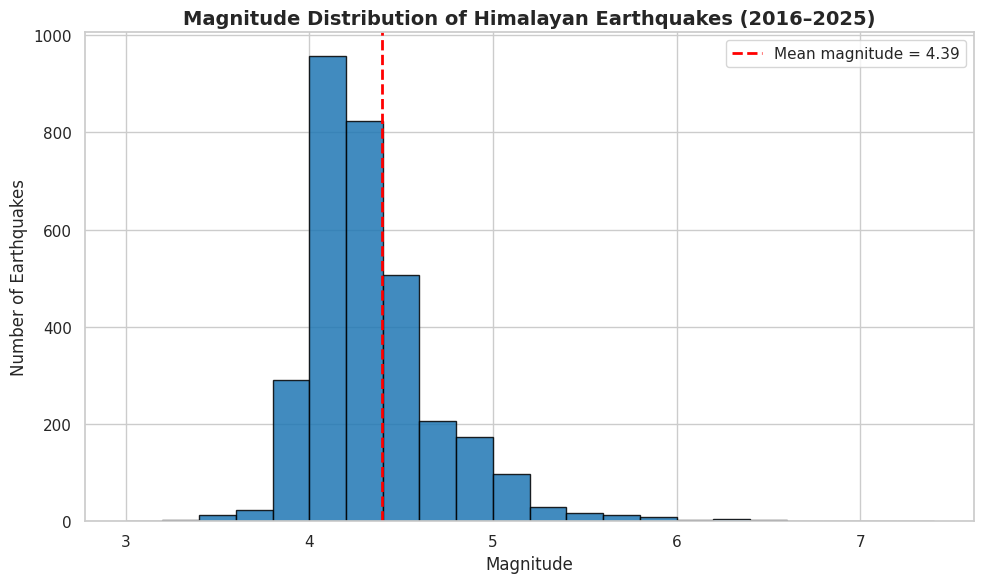

In [7]:
# Histogram of earthquake magnitudes

plt.figure(figsize=(10, 6))

plt.hist(
    eq["mag"],
    bins=np.arange(3.0, 7.6, 0.2),
    color="#1f77b4",
    edgecolor="black",
    alpha=0.85
)

plt.axvline(
    eq["mag"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean magnitude = {eq["mag"].mean():.2f}'
)

plt.title("Magnitude Distribution of Himalayan Earthquakes (2016–2025)", fontsize=14, fontweight="bold")
plt.xlabel("Magnitude", fontsize=12)
plt.ylabel("Number of Earthquakes", fontsize=12)
plt.legend()
plt.tight_layout()

plt.savefig("magnitude_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The catalogue is dominated by moderate earthquakes, with the highest frequency near magnitude 4.1–4.3. Event frequency decreases as magnitude increases, while earthquakes above magnitude 5 are comparatively rare. Since the dataset was filtered to include earthquakes of magnitude 3 and above, low-magnitude events are incomplete and should not be used directly for a Gutenberg–Richter fit. Catalogue completeness will be considered later.

## Earthquake Depth Distribution

Earthquake depth helps distinguish shallow crustal seismicity from intermediate and deep seismicity associated with subduction or lithospheric processes.

In [8]:
# Classify earthquakes by focal depth

def depth_category(depth):
    if depth < 70:
        return "Shallow (<70 km)"
    elif depth < 300:
        return "Intermediate (70–300 km)"
    else:
        return "Deep (≥300 km)"

eq["depth_category"] = eq["depth"].apply(depth_category)

# Count earthquakes in each depth category
depth_counts = eq["depth_category"].value_counts(
    sort=False
).reindex(
    ["Shallow (<70 km)", "Intermediate (70–300 km)", "Deep (≥300 km)"]
)

print(depth_counts)

depth_category
Shallow (<70 km)            1805
Intermediate (70–300 km)    1368
Deep (≥300 km)                 1
Name: count, dtype: int64


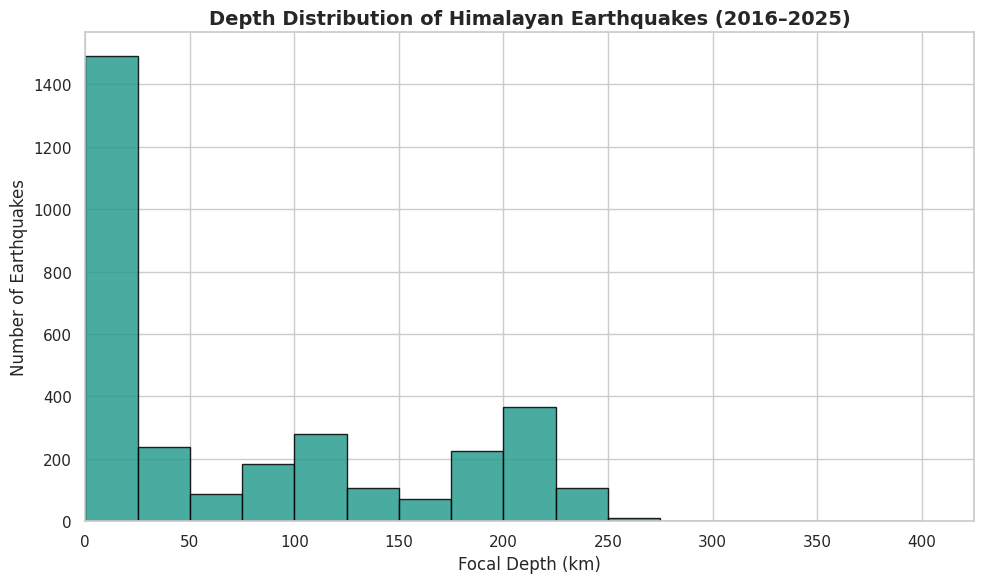

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    eq["depth"],
    bins=np.arange(0, 425, 25),
    color="#2a9d8f",
    edgecolor="black",
    alpha=0.85
)

plt.title("Depth Distribution of Himalayan Earthquakes (2016–2025)",
          fontsize=14, fontweight="bold")
plt.xlabel("Focal Depth (km)", fontsize=12)
plt.ylabel("Number of Earthquakes", fontsize=12)
plt.xlim(0, 425)
plt.tight_layout()

plt.savefig("depth_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Magnitude–Depth Relationship

This plot examines whether earthquake magnitude shows any systematic relationship with focal depth in the selected catalogue.



In [10]:
# Correlation between magnitude and depth
correlation = eq["mag"].corr(eq["depth"])
print(f"Pearson correlation between magnitude and depth: {correlation:.3f}")

Pearson correlation between magnitude and depth: -0.192


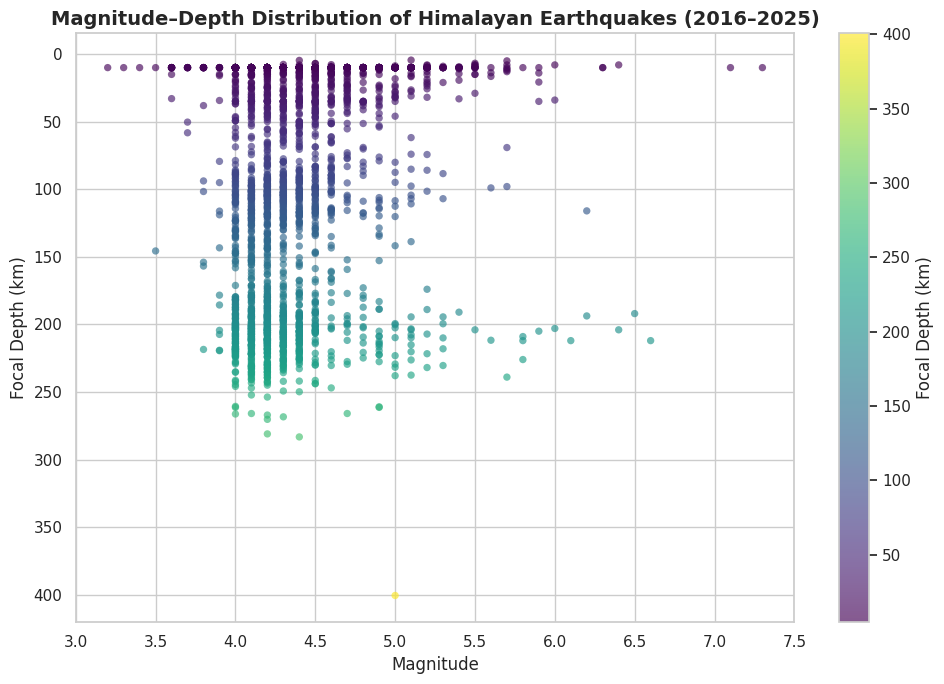

In [11]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    eq["mag"],
    eq["depth"],
    c=eq["depth"],
    cmap="viridis",
    alpha=0.65,
    s=28,
    edgecolors="none"
)

plt.gca().invert_yaxis()  # standard convention: shallow events at top

plt.colorbar(scatter, label="Focal Depth (km)")
plt.title("Magnitude–Depth Distribution of Himalayan Earthquakes (2016–2025)",
          fontsize=14, fontweight="bold")
plt.xlabel("Magnitude", fontsize=12)
plt.ylabel("Focal Depth (km)", fontsize=12)
plt.xlim(3, 7.5)
plt.tight_layout()

plt.savefig("magnitude_vs_depth.png", dpi=300, bbox_inches="tight")
plt.show()

## Spatial Distribution of Himalayan Earthquakes

This map visualises earthquake locations. Marker size represents magnitude, while colour represents focal depth.

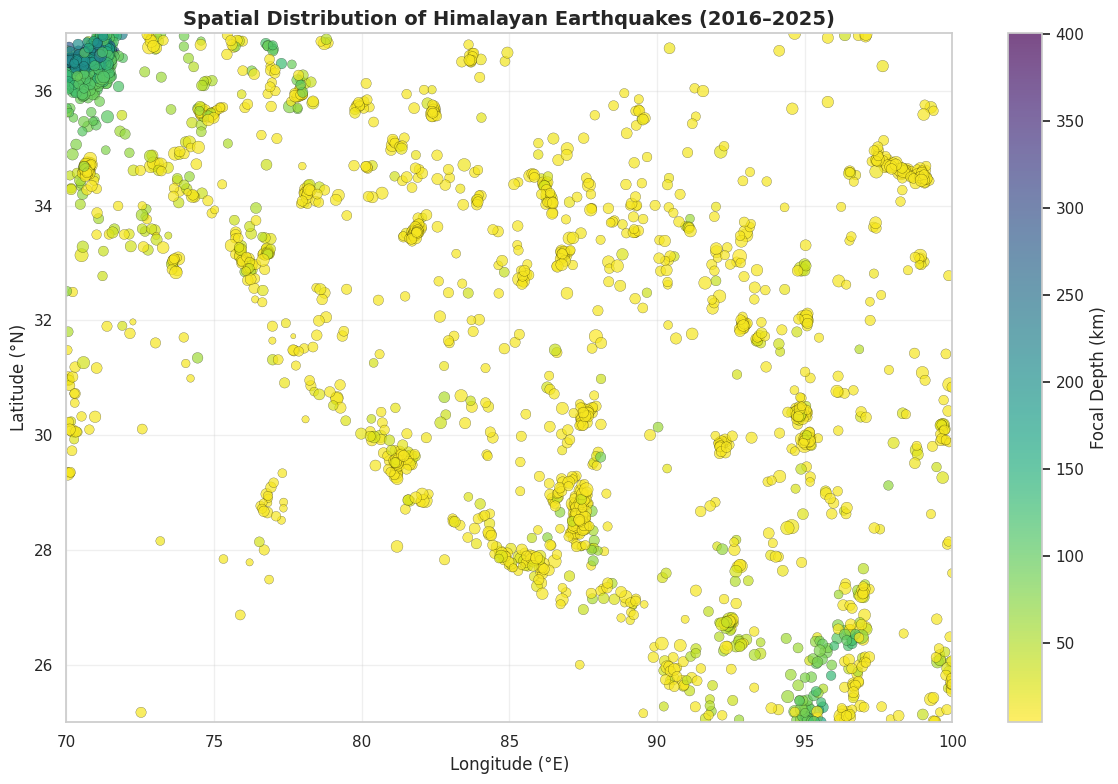

In [12]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    eq["longitude"],
    eq["latitude"],
    s=(eq["mag"] - 3 + 0.2) * 35,
    c=eq["depth"],
    cmap="viridis_r",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

plt.colorbar(scatter, label="Focal Depth (km)")

plt.title("Spatial Distribution of Himalayan Earthquakes (2016–2025)",
          fontsize=14, fontweight="bold")
plt.xlabel("Longitude (°E)", fontsize=12)
plt.ylabel("Latitude (°N)", fontsize=12)
plt.xlim(70, 100)
plt.ylim(25, 37)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("himalayan_earthquake_map.png", dpi=300, bbox_inches="tight")
plt.show()

## Temporal Distribution of Earthquakes

This section examines annual changes in the number of recorded earthquakes within the study region.

In [13]:
# Create a year column
eq["year"] = eq["time"].dt.year

# Count earthquakes per year
yearly_counts = eq.groupby("year").size()

print(yearly_counts)

year
2016    331
2017    256
2018    263
2019    274
2020    352
2021    344
2022    323
2023    314
2024    309
2025    408
dtype: int64


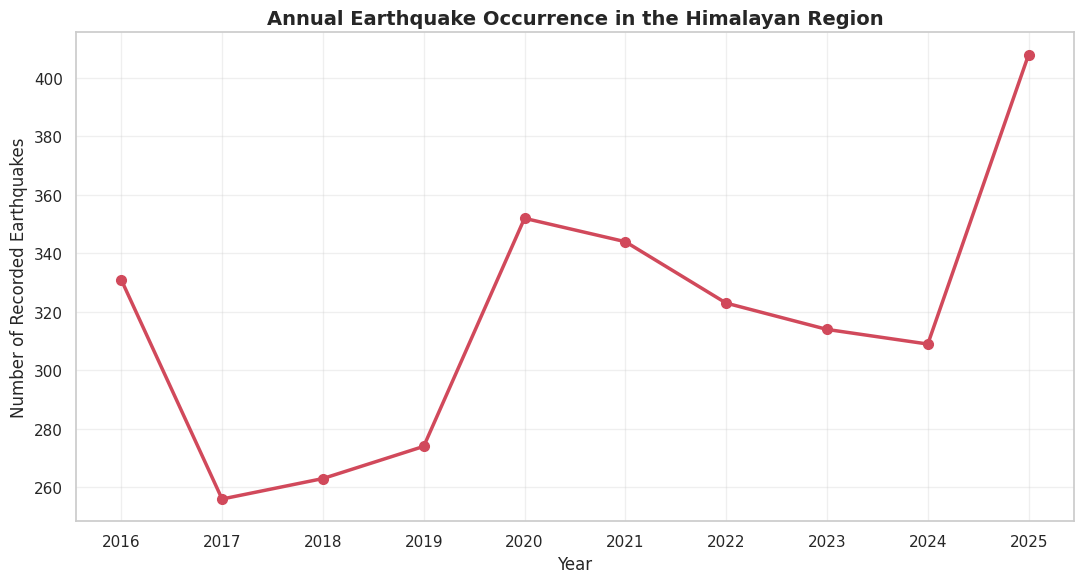

In [14]:
plt.figure(figsize=(11, 6))

plt.plot(
    yearly_counts.index,
    yearly_counts.values,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#d1495b"
)

plt.title("Annual Earthquake Occurrence in the Himalayan Region",
          fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Recorded Earthquakes", fontsize=12)
plt.xticks(yearly_counts.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("annual_earthquake_occurrence.png", dpi=300, bbox_inches="tight")
plt.show()

## Gutenberg–Richter Magnitude–Frequency Relation

The Gutenberg–Richter law describes the decrease in earthquake frequency with increasing magnitude:

\[
\log_{10}N = a - bM
\]

Only events above the estimated magnitude of completeness (\(M_c\)) are used to calculate the b-value.

In [15]:
# Use 0.1 magnitude intervals, matching the catalogue precision
magnitude_step = 0.1
magnitudes = np.arange(3.0, 7.5, magnitude_step)

# Number of earthquakes with magnitude greater than or equal to each magnitude
cumulative_count = np.array([
    (eq["mag"] >= magnitude).sum()
    for magnitude in magnitudes
])

# Estimate magnitude of completeness (Mc) by maximum curvature:
# the most frequent magnitude bin
rounded_magnitudes = eq["mag"].round(1)
Mc = rounded_magnitudes.value_counts().idxmax()

print(f"Estimated magnitude of completeness (Mc): {Mc:.1f}")

Estimated magnitude of completeness (Mc): 4.2


In [16]:
# Keep only earthquakes at or above Mc
complete_catalogue = eq[eq["mag"] >= Mc].copy()

# Maximum-likelihood estimate of b-value
b_value = np.log10(np.e) / (
    complete_catalogue["mag"].mean() - (Mc - magnitude_step / 2)
)

# a-value: overall seismic activity level for this selected catalogue
a_value = np.log10(len(complete_catalogue)) + b_value * Mc

print(f"Earthquakes used for b-value: {len(complete_catalogue)}")
print(f"a-value: {a_value:.2f}")
print(f"b-value: {b_value:.2f}")

Earthquakes used for b-value: 2422
a-value: 8.51
b-value: 1.22


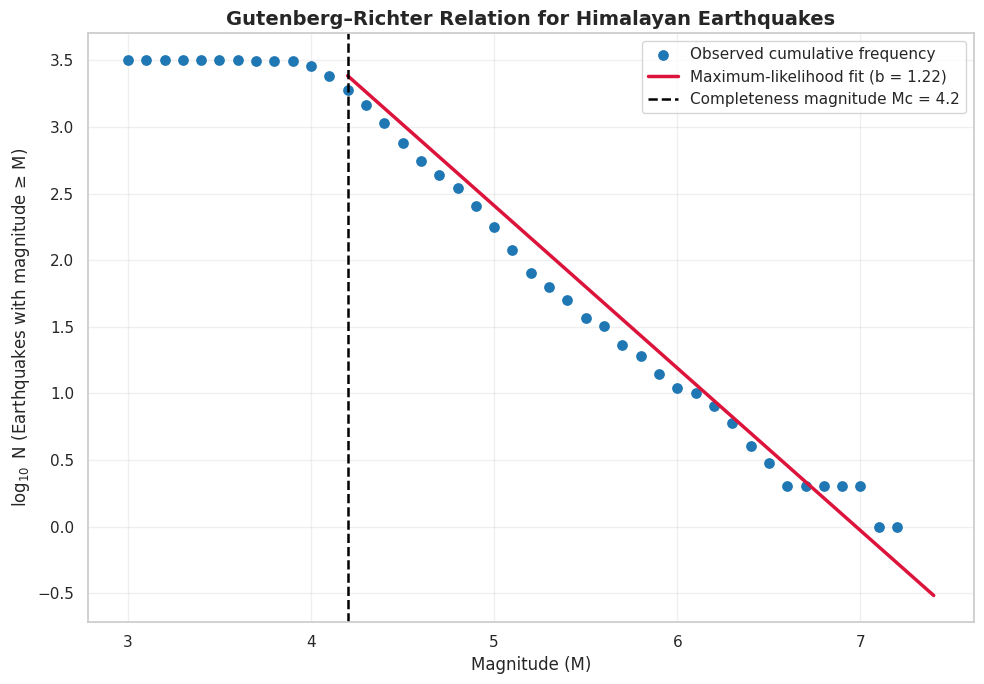

In [17]:
# Use only non-zero cumulative frequencies
valid = cumulative_count > 0

# Gutenberg–Richter model line
fit_magnitudes = magnitudes[magnitudes >= Mc]
fit_logN = a_value - b_value * fit_magnitudes

plt.figure(figsize=(10, 7))

plt.scatter(
    magnitudes[valid],
    np.log10(cumulative_count[valid]),
    color="#1f77b4",
    s=45,
    label="Observed cumulative frequency"
)

plt.plot(
    fit_magnitudes,
    fit_logN,
    color="crimson",
    linewidth=2.5,
    label=f"Maximum-likelihood fit (b = {b_value:.2f})"
)

plt.axvline(
    Mc,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label=f"Completeness magnitude Mc = {Mc:.1f}"
)

plt.title("Gutenberg–Richter Relation for Himalayan Earthquakes",
          fontsize=14, fontweight="bold")
plt.xlabel("Magnitude (M)", fontsize=12)
plt.ylabel(r"$\log_{10}$ N (Earthquakes with magnitude ≥ M)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("gutenberg_richter_relation.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The cumulative magnitude–frequency distribution follows an approximately linear Gutenberg–Richter trend above the estimated completeness magnitude, Mc = 4.2. Using a maximum-likelihood method, the b-value was estimated as 1.22.

This indicates that, within the selected catalogue, moderate earthquakes are considerably more frequent than larger earthquakes. The b-value should be interpreted cautiously because the study region covers multiple tectonic settings and contains different reported magnitude types. It is a catalogue-level seismicity result, not a local hazard estimate.

In [18]:
import os
import shutil
from google.colab import files

# Create GitHub project folders
os.makedirs("earthquake_project/data", exist_ok=True)
os.makedirs("earthquake_project/figures", exist_ok=True)

# Save cleaned catalogue
eq.to_csv(
    "earthquake_project/data/himalayan_earthquake_catalogue.csv",
    index=False
)

# Move figure files into figures folder
figure_files = [
    "magnitude_distribution.png",
    "depth_distribution.png",
    "magnitude_vs_depth.png",
    "himalayan_earthquake_map.png",
    "annual_earthquake_occurrence.png",
    "gutenberg_richter_relation.png"
]

for file_name in figure_files:
    if os.path.exists(file_name):
        shutil.copy(file_name, f"earthquake_project/figures/{file_name}")

# Create a ZIP file for download
shutil.make_archive("earthquake_project", "zip", "earthquake_project")

print("Project files prepared successfully!")
files.download("earthquake_project.zip")

Project files prepared successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>